In [3]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Success! Project root added: {parent_dir}")
print("Available folders here:", os.listdir(parent_dir))

Success! Project root added: c:\Users\arsal\OneDrive\Desktop\Study Stuff\Projects\AIML\Data Analysis\solar-performance-intelligence
Available folders here: ['.git', '.gitignore', 'data', 'LICENSE', 'README.md', 'reports', 'scripts', 'solar-power-generation-and-energy-consumption-data.zip', 'src']


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config.settings import PROCESSED_DIR

In [5]:
pd.set_option(
    "display.max_columns",
    None
)

In [9]:
master_df = pd.read_parquet(PROCESSED_DIR / "master_dataset.parquet")
master_df.head(10)

,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection,CloudOpacity,Ghi,kWp,Number of panels,lat,Lon,has_capacity_data
0,2,1,2020-01-01 00:15:00,0.0,18.560000,20.300000,9.600000,50.266667,8.680000,152.666667,0.0,1025.75,NaN,NaN,-36.111209,146.848679,0
1,2,1,2020-01-01 00:30:00,0.0,18.146667,19.840000,9.340000,50.666667,7.933333,157.533333,0.0,1046.50,NaN,NaN,-36.111209,146.848679,0
2,2,1,2020-01-01 00:45:00,0.0,18.140000,19.886667,9.486667,51.000000,8.440000,147.600000,0.0,1067.25,NaN,NaN,-36.111209,146.848679,0
3,2,1,2020-01-01 01:00:00,0.0,17.693333,19.540000,9.180000,51.133333,8.680000,151.333333,0.0,1088.00,NaN,NaN,-36.111209,146.848679,0
4,2,1,2020-01-01 01:15:00,0.0,17.613333,19.153333,9.053333,51.933333,6.866667,149.333333,0.0,1092.75,NaN,NaN,-36.111209,146.848679,0
5,2,1,2020-01-01 01:30:00,0.0,16.906667,18.873333,9.153333,53.266667,9.253333,163.466667,0.0,1097.50,NaN,NaN,-36.111209,146.848679,0
6,2,1,2020-01-01 01:45:00,0.0,16.713333,18.460000,8.886667,53.666667,7.666667,167.333333,0.0,1102.25,NaN,NaN,-36.111209,146.848679,0
7,2,1,2020-01-01 02:00:00,0.0,16.953333,18.893333,9.133333,53.133333,9.040000,153.400000,0.0,1107.00,NaN,NaN,-36.111209,146.848679,0
8,2,1,2020-01-01 02:15:00,0.0,17.060000,19.033333,8.940000,52.000000,9.040000,154.933333,0.0,1094.75,NaN,NaN,-36.111209,146.848679,0
9,2,1,2020-01-01 02:30:00,0.0,16.646667,19.040000,8.953333,52.000000,11.080000,146.266667,0.0,1082.50,NaN,NaN,-36.111209,146.848679,0


In [35]:
eda_df = master_df[
    master_df["SolarGeneration"] > 0
].copy()

In [12]:
print(master_df.shape)
print(f"\nColums:\n{master_df.columns.tolist()}\n\n")
print(f"\n{master_df.info()}")

(2731946, 17)

Colums:
['CampusKey', 'SiteKey', 'Timestamp', 'SolarGeneration', 'ApparentTemperature', 'AirTemperature', 'DewPointTemperature', 'RelativeHumidity', 'WindSpeed', 'WindDirection', 'CloudOpacity', 'Ghi', 'kWp', 'Number of panels', 'lat', 'Lon', 'has_capacity_data']


<class 'pandas.DataFrame'>
RangeIndex: 2731946 entries, 0 to 2731945
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   CampusKey            int64         
 1   SiteKey              int64         
 2   Timestamp            datetime64[us]
 3   SolarGeneration      float64       
 4   ApparentTemperature  float64       
 5   AirTemperature       float64       
 6   DewPointTemperature  float64       
 7   RelativeHumidity     float64       
 8   WindSpeed            float64       
 9   WindDirection        float64       
 10  CloudOpacity         float64       
 11  Ghi                  float64       
 12  kWp                  float64       
 1

In [13]:
master_df.describe()

,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection,CloudOpacity,Ghi,kWp,Number of panels,lat,Lon,has_capacity_data
count,2.731946e+06,2.731946e+06,2731946,2.425081e+06,2.103489e+06,2.103489e+06,2.103489e+06,2.103489e+06,1.550513e+06,1.550513e+06,2.699161e+06,2.699161e+06,1.599868e+06,1.599868e+06,2.731946e+06,2.731946e+06,2.731946e+06
mean,1.706099e+00,2.169464e+01,2021-05-05 00:27:30.469225,3.423850e+00,1.304846e+01,1.502757e+01,9.244646e+00,7.288863e+01,1.054040e+01,1.918686e+02,2.617589e+01,1.924553e+02,9.532623e+01,2.725146e+02,-3.720286e+01,1.450534e+02,5.856148e-01
min,1.000000e+00,1.000000e+00,2020-01-01 00:15:00,0.000000e+00,-6.633333e+00,-2.706667e+00,-1.147333e+01,3.066667e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.139000e+01,6.900000e+01,-3.771829e+01,1.421666e+02,0.000000e+00
25%,1.000000e+00,1.100000e+01,2020-11-14 17:30:00,0.000000e+00,8.100000e+00,1.050000e+01,6.320000e+00,5.653333e+01,5.266667e+00,1.321333e+02,7.500000e-02,0.000000e+00,3.927000e+01,1.190000e+02,-3.771829e+01,1.450510e+02,0.000000e+00
50%,1.000000e+00,2.200000e+01,2021-05-16 02:30:00,0.000000e+00,1.214000e+01,1.423333e+01,8.926667e+00,7.460000e+01,9.880000e+00,1.990000e+02,1.730000e+01,1.950000e+01,5.115000e+01,1.550000e+02,-3.771829e+01,1.450510e+02,1.000000e+00
75%,2.000000e+00,3.300000e+01,2021-11-04 07:30:00,3.248047e+00,1.744667e+01,1.880000e+01,1.190000e+01,9.400000e+01,1.494000e+01,2.570667e+02,4.710000e+01,3.197500e+02,7.722000e+01,2.340000e+02,-3.677886e+01,1.450510e+02,1.000000e+00
max,5.000000e+00,4.200000e+01,2022-04-23 23:45:00,9.921880e+01,4.158667e+01,4.540000e+01,2.532000e+01,1.000000e+02,5.640000e+01,3.580667e+02,9.700000e+01,1.128000e+03,5.398000e+02,1.240920e+03,-3.420529e+01,1.468487e+02,1.000000e+00
std,1.054196e+00,1.230951e+01,NaN,8.598325e+00,6.927730e+00,6.544982e+00,4.088917e+00,2.206263e+01,7.437660e+00,8.729898e+01,2.738829e+01,2.769156e+02,1.233715e+02,3.055991e+02,7.918724e-01,8.634530e-01,4.926157e-01


In [37]:
eda_df[
    [
        "SolarGeneration",
        "Ghi",
        "AirTemperature",
        "RelativeHumidity",
        "WindSpeed"
    ]
].describe()

,SolarGeneration,Ghi,AirTemperature,RelativeHumidity,WindSpeed
count,1.195645e+06,1.181498e+06,906336.000000,906336.000000,648873.000000
mean,6.944463e+00,1.550634e+01,17.903866,62.541792,13.198621
std,1.120282e+01,5.397358e+01,6.544697,21.824823,7.178656
min,1.000000e-01,0.000000e+00,-1.873333,3.066667,0.000000
25%,1.128906e+00,0.000000e+00,13.253333,47.000000,8.213333
50%,3.328125e+00,0.000000e+00,16.986667,60.800000,12.520000
75%,8.062500e+00,0.000000e+00,21.900000,78.000000,17.540000
max,9.921880e+01,1.068500e+03,45.400000,100.000000,55.253333


# Target Analysis
Target: SolarGeneration

In [38]:
eda_df["SolarGeneration"].describe()

count    1.195645e+06
mean     6.944463e+00
std      1.120282e+01
min      1.000000e-01
25%      1.128906e+00
50%      3.328125e+00
75%      8.062500e+00
max      9.921880e+01
Name: SolarGeneration, dtype: float64

# Inference
It seems the mean is ~3.42 kWh of solar geneartion over the 2.42 million rowsm with a standard deviation of ~8.59. The minimum value is 0.0 while the max is ~99.21 kWh, we can also 50% of the values are 0.0 and it can be seen that 75%ile shows ~3.25 kWh genration. <br>
The main crux of this is that, the dataset is HEAVILY SKEWED to the left side, since we can see that median is less than mean, and the max elements is insanely large, dragging the mean of the dataset UP. <bt>
The Below Hist Plot can show the left-skewness of the dataset.

<Axes: xlabel='SolarGeneration', ylabel='Count'>

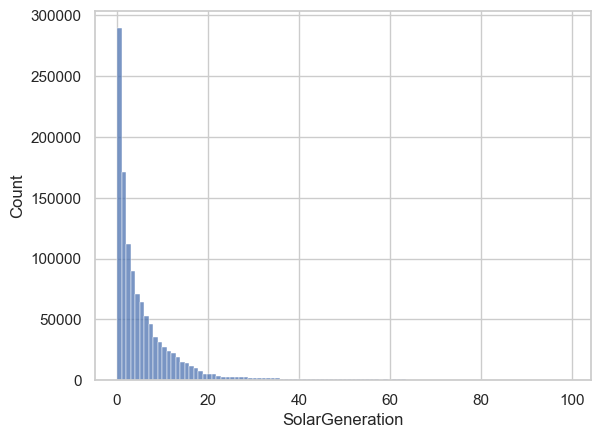

In [39]:
sns.histplot(
    eda_df["SolarGeneration"],
    bins=100
)

# Campus Analysis

<Axes: xlabel='CampusKey', ylabel='SolarGeneration'>

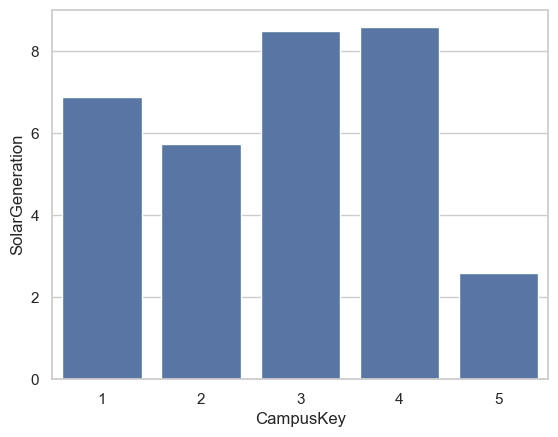

In [40]:
mean_solar_campus_wise = eda_df.groupby("CampusKey")["SolarGeneration"].mean().reset_index()
sns.barplot(x="CampusKey", y="SolarGeneration", data=mean_solar_campus_wise)

# Inference
It can be seen that campus 5 generates the least amount of solar energy on mean average while campus 4 generates the most, and we can kinda see a close proximity in the mean energy generation of campuses 1, 2, 3, and 4, while campus 5 has the poorest performance. This Plust the initial data qualitiy phase analysis, shows something is up with data wrt to campus 5 as we know its systemic error, and its with campus 5 mostly.

# Sectional Analysis

<Axes: xlabel='Month', ylabel='SolarGeneration'>

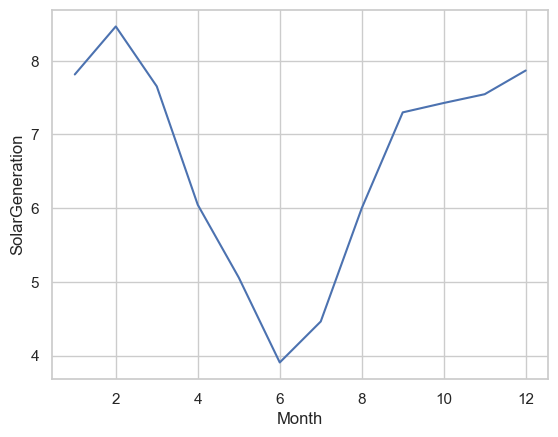

In [41]:
eda_df["Month"] = eda_df["Timestamp"].dt.month
solar_gen_mean_month_wise = eda_df.groupby("Month")["SolarGeneration"].mean().reset_index()
sns.lineplot(x="Month", y="SolarGeneration", data=solar_gen_mean_month_wise)

# Inference
First lets understand Australia's Season Cycle, Dec-Feb is Summer, March-May is Autumn, Jun-Aug is Winter, and Sept-Nov is Spring, while in some parts of Aus it is divided into Wet Season (Nov-Apr) and Dry Season (May-Oct) <br>
It can be seen through the graph that the energy generation has be on increase from june with pace up increase in July, while we seee the peaks of generation of second half mostly during summer <br>
It can also be seen that the energy generation peaked during february at ~4.5 kWh, and was the lowest during june at ~1 kWh. <br>
Conclusion: Weather seems to be affecting the effectives of SolarGeneration It seems

## nicer way
Solar generation exhibits strong seasonal behavior.
Production peaks during Australian summer months
(Jan-Feb-Dec)

Production bottoms during winter
(Jun-Jul)

This confirms that environmental conditions
strongly influence generation performance.

# Hourly Analysis

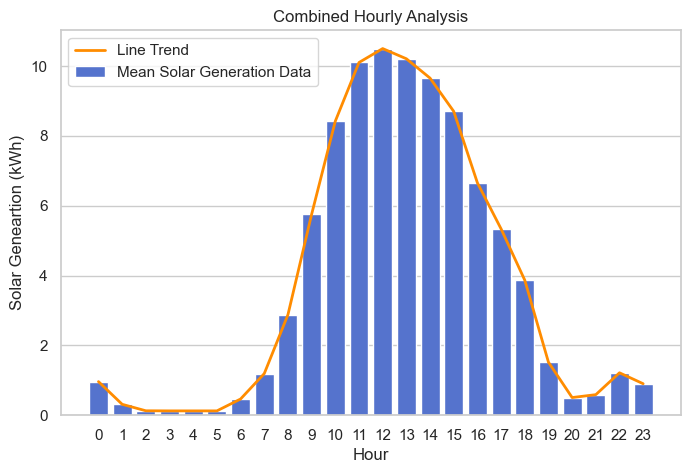

In [42]:
eda_df["Hour"] = eda_df["Timestamp"].dt.hour
mean_solar_gen_hourly = eda_df.groupby("Hour")["SolarGeneration"].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=mean_solar_gen_hourly, x="Hour", y="SolarGeneration", color="royalblue", label="Mean Solar Generation Data")
sns.lineplot(data=mean_solar_gen_hourly, x="Hour", y="SolarGeneration", color="darkorange", markers="o", linewidth=2, label="Line Trend")

plt.title("Combined Hourly Analysis")
plt.ylabel("Solar Geneartion (kWh)")
plt.legend()

plt.show()

# Inference
It can be seen that the solar generation is mostly done from 7-19, with slight amount of generation during 6 and 20 and it gradually decreases <br>
It also shows a pretty even distribution not ideal uniform but somewhat uniform, and a very predictive trend can be seen with the lineplot <br>
Conclusion: It seems during the night the solargeneration is zero, and daytime does the most geneartion as per hour vs sunlight effectivity, which is normal. Dataset is predictive

## nicer way
Generation follows a highly predictable
diurnal cycle.

Production begins around sunrise,
peaks near solar noon,
and declines toward sunset.

This pattern suggests
strong temporal predictability,
making time-based features highly valuable
for downstream modeling.

# Weather v/s Output

In [29]:
sns.set_theme(style='whitegrid')

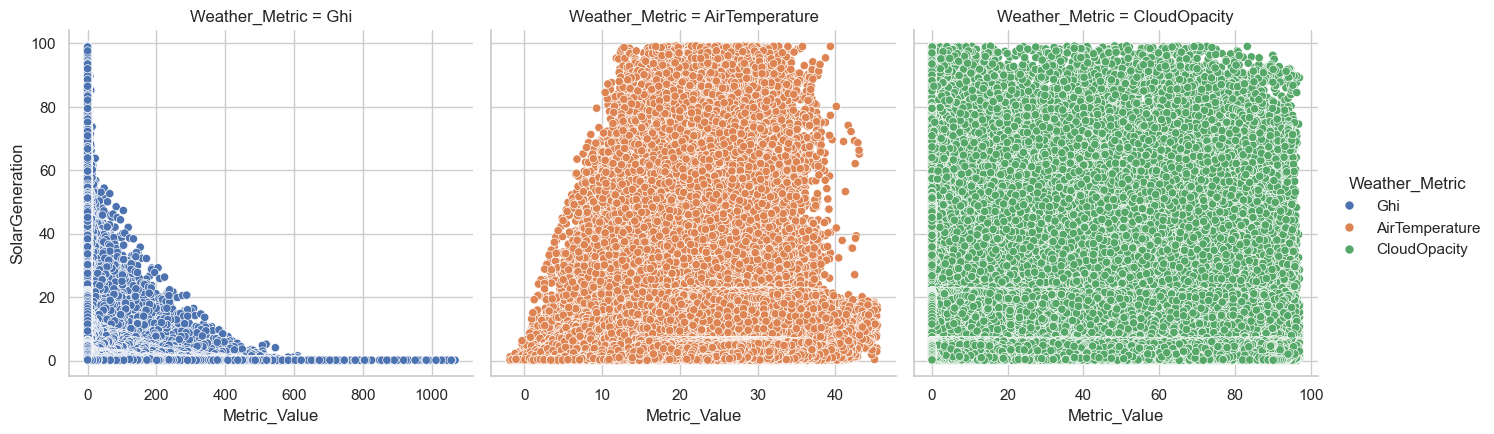

In [43]:
r_col = ["SolarGeneration", "Ghi", "AirTemperature", "CloudOpacity"]
r_df = eda_df[r_col]
r_df_long = pd.melt(
    r_df,
    id_vars=["SolarGeneration"],
    value_vars=["Ghi", "AirTemperature", "CloudOpacity"],
    var_name="Weather_Metric",
    value_name="Metric_Value"
)

sns.relplot(
    data=r_df_long,
    x="Metric_Value",
    y="SolarGeneration",
    col="Weather_Metric",
    hue="Weather_Metric",
    kind="scatter",
    facet_kws={'sharex': False},
    height=4.5,
    aspect=1
)

plt.show()

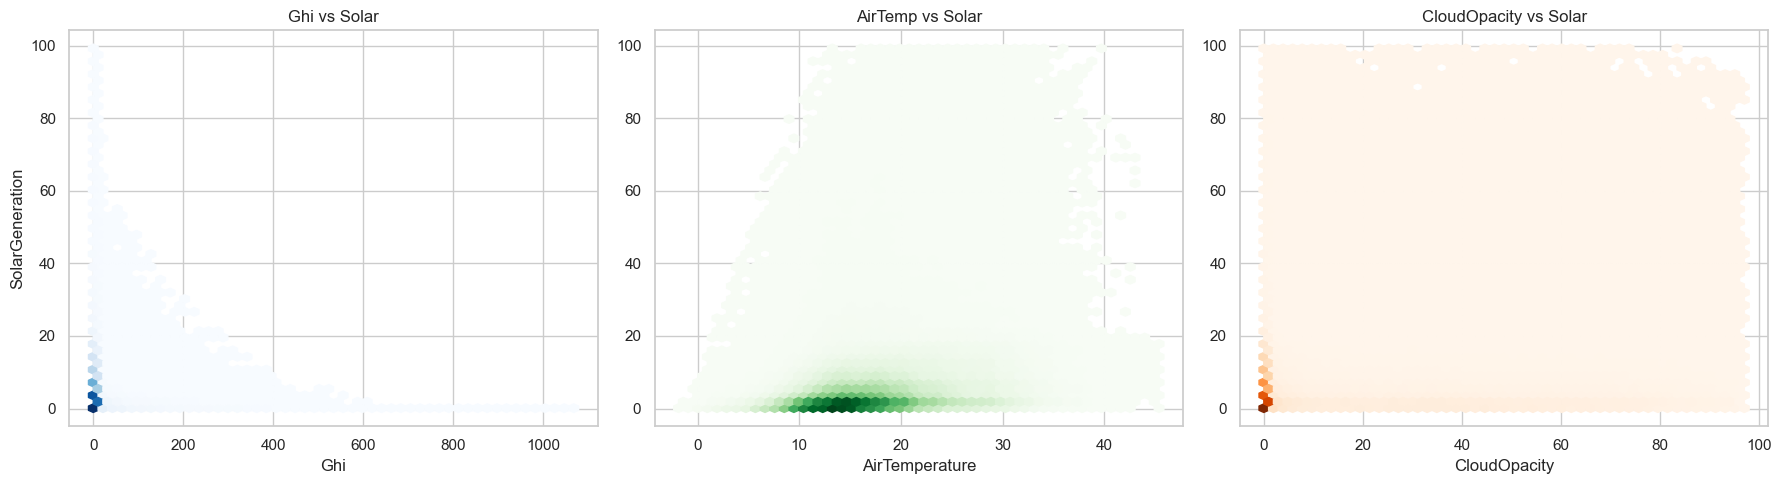

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hexbin(eda_df["Ghi"], eda_df["SolarGeneration"], gridsize=50, cmap="Blues", mincnt=1)
axes[0].set_title("Ghi vs Solar")
axes[0].set_xlabel("Ghi")
axes[0].set_ylabel("SolarGeneration")

axes[1].hexbin(eda_df["AirTemperature"], eda_df["SolarGeneration"], gridsize=50, cmap="Greens", mincnt=1)
axes[1].set_title("AirTemp vs Solar")
axes[1].set_xlabel("AirTemperature")

axes[2].hexbin(eda_df["CloudOpacity"], eda_df["SolarGeneration"], gridsize=50, cmap="Oranges", mincnt=1)
axes[2].set_title("CloudOpacity vs Solar")
axes[2].set_xlabel("CloudOpacity")

plt.tight_layout()
plt.show()


# Inference
What I can infer not from scatter plot, its too dense to infer from it, I will infer from hexbin charts, since we can see the exact concentration of the relation of data, like we can se someowhat of a dense relation of ghi and solar at 0 and vertically up and horizontally right it somewhat becomes weak realtion, and there are white hexbins indicating only very scarce points, indicating, that a very low ghi produces low solar, and the dataset we got, has mostly been in that region meaning distribution is not really balanced there <br>
As for air temp vs solar, we can see despite temperatureincrease most solr value is 0 which shows that there is not much of a relation other than some outliers like the white area datapoints bins <br>
finally cloudopacity we can see only 0 opacity has 0 geneartion for the most part and from previous we can infer some of them are from nighttime, and majority of daytime is scattered as we can see from the scatterplot

<Axes: >

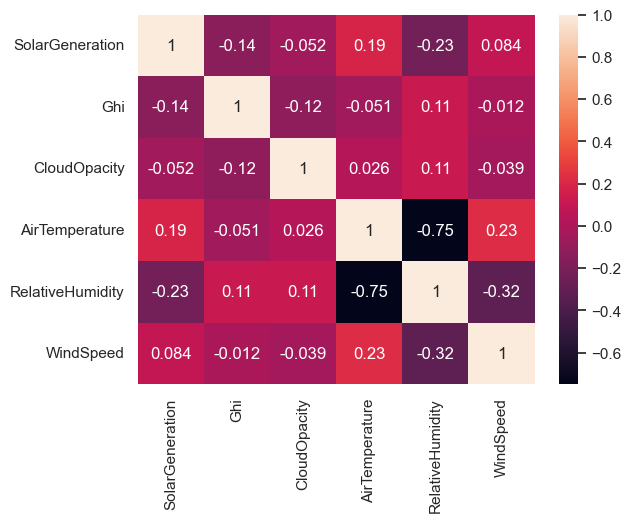

In [45]:
corr_cols = [
    "SolarGeneration",
    "Ghi",
    "CloudOpacity",
    "AirTemperature",
    "RelativeHumidity",
    "WindSpeed"
]

corr = (
    eda_df[corr_cols]
    .corr()
)

sns.heatmap(
    corr,
    annot=True
)

# Somee hypothesis for Campus 5
A. Poor telemetry: it is due to poor telemetry that we see the missing values <br>
B. It has a smaller installation of solar panel arrays due to which some readings are often missed<br>
C. It might be due to later setup of the Campus 5 (one can prove this hypothesis with the below query)

In [48]:
master_df.groupby("CampusKey")["Timestamp"].min()

CampusKey
1   2020-01-01 00:15:00
2   2020-01-01 00:15:00
3   2020-01-01 00:15:00
4   2020-01-01 00:15:00
5   2020-01-01 00:15:00
Name: Timestamp, dtype: datetime64[us]

## Hypothesis C
As it can be seen that the start it has is the same as other campuses, so it is shown that hypothesis C is not possible, and since Hypothesis A and B are not possible to prove unless in contact with said body, we may assume A or B is true, since at the end it does not matter as both are systemic errors.

In [49]:
master_df["GenerationPerkWp"] = (
    master_df["SolarGeneration"]
    / master_df["kWp"]
)